# Setting up a latent function Gaussian Process for H(z)

In [1]:
# import set 
using Turing
using Distances
using LinearAlgebra
using LimberJack
using Interpolations
using GaussianProcess
using Plots
using QuadGK
using BlockDiagonals
using CSV
using DataFrames
using PrettyTables
import LimberJack.TkEisHu
using NumericalIntegration

### Collate data

In [2]:
# assumed parameter distributions
omegam_dist = truncated(Normal(0.3,0.2),0.01,0.99);
h0_dist = Uniform(0.5,0.8);
s8_dist = Normal(0.8,0.5);
rd_dist = Normal(147,5);
M_dist = Normal(-19.2, 1);

#### Data

In [3]:
# hz data
function data_hz()
    z = [
        0.07, 0.09, 0.12, 0.17, 0.179, 0.199, 0.2,
        0.27, 0.28, 0.352, 0.38, 0.3802, 0.4,
        0.4004, 0.4247, 0.44, 0.4497, 0.47, 0.4783,
        0.48, 0.51, 0.593, 0.6, 0.61, 0.68, 0.73,
        0.781, 0.875, 0.88, 0.9, 1.037, 1.3,
        1.363, 1.43, 1.53, 1.75, 1.965
    ]

    data = [
        69.0, 69.0, 68.6, 83.0, 75.0, 75.0, 72.9,
        77.0, 88.8, 83.0, 81.5, 83.0, 95.0, 77.0,
        87.1, 82.6, 92.8, 89.0, 80.9, 97.0, 90.4,
        104.0, 87.9, 97.3, 92.0, 97.3, 105.0,
        125.0, 90.0, 117.0, 154.0, 168.0, 160.0,
        177.0, 140.0, 202.0, 186.5
    ]

    err = [
        19.6, 12.0, 26.2, 8.0, 4.0, 5.0, 29.6,
        14.0, 36.6, 14.0, 1.9, 13.5, 17.0, 10.2,
        11.2, 7.8, 12.9, 23.0, 9.0, 62.0, 1.9,
        13.0, 6.1, 2.1, 8.0, 7.0, 12.0, 17.0,
        40.0, 23.0, 20.0, 17.0, 33.6, 18.0,
        14.0, 40.0, 50.4
    ]

    cov = zeros(length(z), length(z))
    for i in 1:length(z)
        cov[i, i] = err[i]^2
    end

    return (
        data_name = "data_hz",
        z = z,
        data = data,
        err = err,
        cov = cov
    )
end


data_hz (generic function with 1 method)

In [4]:
# function data_DESI()
#     # DESI data
#     z1 = [0.3, 0.51, 0.71, 0.92, 1.32, 1.49]
#     z = repeat(z1, inner = 4)
#     data_dvrd = [7.788174, 12.514437, 15.675560, 19.676985, 23.861806, 25.708520]
#     data_dhdm = [3.053800, 1.637266, 1.165867, 0.844996, 0.470709, 0.426508] 
#     data_fss8 = [0.377174, 0.513635, 0.483623, 0.422164, 0.376715, 0.434858]
#     data_m = [-0.031370, 0.027840, 0.046650, -0.024690, 0.059960, 0.064550]
    
#     data = 
#     [7.788174, 3.053800, 0.377174, -0.031370,    # BGS (z=0.30)
#     12.514437, 1.637266, 0.513635, 0.027840, # LRG1 (z=0.51)
#     15.675560, 1.165867, 0.483623, 0.046650,  # LRG2 (z=0.71)
#     19.676985, 0.844996, 0.422164, -0.024690, # LRG3 (z=0.92)
#     23.861806, 0.470709, 0.376715, 0.059960,  # ELG2 (z=1.32)
#     25.708520, 0.426508, 0.434858, 0.064550]   # QSO (z=1.49)

#     # Full 18x18 Covariance Matrix for DESI 2024 Year 1 
#     # Variables: [DV/rd, DH/DM, fσs8] per redshift bin
#     # Source: arXiv:2411.12021 Appendix A
#     C_total = zeros(24, 24);

#     # BGS z=0.30
#     C_total[1:4, 1:4] = [1314.664401  -142.669742   109.427163  -217.509715;
#                 -142.669742   829.170940  -158.101737   -61.084426;
#                  109.427163  -158.101737    88.510877    -2.272457;
#                 -217.509715   -61.084426    -2.272457   279.702360] .* 1e-4

#     # LRG1, zeff = 0.51
#     C_total[5:8, 5:8] = [541.309833   48.425593    -4.652853   -37.707751;
#                         48.425593   97.249820   -34.923265   -14.418597;
#                         -4.652853  -34.923265    41.295470    15.405508;
#                         -37.707751  -14.418597    15.405508    48.918910] .* 1e-4

#     # LRG2, zeff = 0.71
#     C_total[9:12, 9:12] = [762.457717   39.781004    -1.896006   -62.812849;
#                             39.781004   36.344098   -17.341350    -8.333900;
#                             -1.896006  -17.341350    28.119682     8.865225;
#                         -62.812849   -8.333900     8.865225    47.624520] .* 1e-4

#     # LRG3, zeff = 0.92
#     C_total[13:16, 13:16] = [847.499793   26.038900     3.257324   -37.016091;
#                             26.038900   16.251088   -10.044074    -3.698790;
#                             3.257324  -10.044074    22.370314     6.467510;
#                             -37.016091   -3.698790     6.467510    34.883220] .* 1e-4

#     # ELG2, zeff = 1.32
#     C_total[17:20, 17:20] = [2342.506886   26.159601    13.521001   -95.336060;
#                                 26.159601   10.309303    -6.654663    -5.183903;
#                                 13.521001   -6.654663    13.997473     9.109619;
#                             -95.336060   -5.183903     9.109619    43.575710] .* 1e-4

#     # QSO, zeff = 1.49
#     C_total[21:24, 21:24] = [3013.788566   -2.205101    36.332110   -98.167826;
#                                 -2.205101    5.845806    -6.747133    -1.913326;
#                                 36.332110   -6.747133    19.785658     5.357546;
#                             -98.167826   -1.913326     5.357546    26.266260] .* 1e-4

    
#     cov = C_total
    
#     err_arr = sqrt.(diag(cov))
#     err_dvrd = err_arr[1:4:end]
#     err_dhdm = err_arr[2:4:end]
#     err_fss8 = err_arr[3:4:end]
#     err_m = err_arr[4:4:end]

#     return(data_name = "data_DESI", z1 = z1, z = z, data = data, data_dvrd = data_dvrd, data_dhdm = data_dhdm, data_fss8 = data_fss8, data_m = data_m, err_dvrd = err_dvrd, err_dhdm = err_dhdm, err_fss8 = err_fss8, err_m = err_m, cov = cov)
# end

In [5]:
function data_DESI()
    # DESI data
    z1 = [0.3, 0.51, 0.71, 0.92, 1.32, 1.49]
    z = repeat(z1, inner = 3)
    data_dvrd = [7.788174, 12.514437, 15.675560, 19.676985, 23.861806, 25.708520]
    data_dhdm = [3.053800, 1.637266, 1.165867, 0.844996, 0.470709, 0.426508] 
    data_fss8 = [0.377174, 0.513635, 0.483623, 0.422164, 0.376715, 0.434858]
    
    data = 
    [7.788174, 3.053800, 0.377174,   # BGS (z=0.30)
    12.514437, 1.637266, 0.513635, # LRG1 (z=0.51)
    15.675560, 1.165867, 0.483623,  # LRG2 (z=0.71)
    19.676985, 0.844996, 0.422164, # LRG3 (z=0.92)
    23.861806, 0.470709, 0.376715,  # ELG2 (z=1.32)
    25.708520, 0.426508, 0.434858]   # QSO (z=1.49)

    # Full 18x18 Covariance Matrix for DESI 2024 Year 1 
    # Variables: [DV/rd, DH/DM, fσs8] per redshift bin
    # Source: arXiv:2411.12021 Appendix A
    C_total = zeros(18, 18);

    # BGS z=0.30
    C_total[1:3, 1:3] = 1e-4 * [
        1314.664401 -142.669742  109.427163;
        -142.669742  829.170940 -158.101737;
        109.427163 -158.101737   88.510877
    ]

    # LRG1 z=0.51
    C_total[4:6, 4:6] = 1e-4 * [
        541.309833   48.425593   -4.652853;
        48.425593   97.249820  -34.923265;
        -4.652853  -34.923265   41.295470
    ]

    # LRG2 z=0.71
    C_total[7:9, 7:9] = 1e-4 * [
        762.457717   39.781004   -1.896006;
        39.781004   36.344098  -17.341350;
        -1.896006  -17.341350   28.119682
    ]

    # LRG3 z=0.92
    C_total[10:12, 10:12] = 1e-4 * [
        847.499793   26.038900    3.257324;
        26.038900   16.251088  -10.044074;
        3.257324  -10.044074   22.370314
    ]

    # ELG2 z=1.32
    C_total[13:15, 13:15] = 1e-4 * [
    2342.506886   26.159601   13.521001;
        26.159601   10.309303   -6.654663;
        13.521001   -6.654663   13.997473
    ]

    # QSO z=1.49
    C_total[16:18, 16:18] = 1e-4 * [
    3013.788566   -2.205101   36.332110;
        -2.205101    5.845806   -6.747133;
        36.332110   -6.747133   19.785658
    ]

    
    cov = C_total
    
    err_arr = sqrt.(diag(cov))
    err_dvrd = err_arr[1:3:end]
    err_dhdm = err_arr[2:3:end]
    err_fss8 = err_arr[3:3:end]

    return(data_name = "data_DESI", z1 = z1, z = z, data = data, data_dvrd = data_dvrd, data_dhdm = data_dhdm, data_fss8 = data_fss8, err_dvrd = err_dvrd, err_dhdm = err_dhdm, err_fss8 = err_fss8, cov = cov)
end

data_DESI (generic function with 1 method)

In [6]:
dataDESI = data_DESI();
datahz = data_hz();

In [7]:
# fs8 data
function data_combtracer_fs8()

z  = [0.026]
data  = [0.412]
err = 0.018

cov = [err^2;;]

    return (data_name = "data_combtracer_fs8", z = z, data = data, err = err, cov = cov)
end

datatracerfs8 = data_combtracer_fs8();

In [8]:
# Load data
supernovae_raw = CSV.read("DES_Dovekie_HD.csv", DataFrame);
# Find indices that satisfy the condition
keep_idx = findall(supernovae_raw.MUERR .< 1);
# Filter the dataframe
supernovae = supernovae_raw[keep_idx, :];
# Load covariance matrix
supernovae_cov_df = CSV.read("STAT+SYS_dovekie.csv", DataFrame);
supernovae_cov = Matrix(supernovae_cov_df);
# Filter covariance matrix (rows AND columns)
sup_cov_filt = supernovae_cov[keep_idx, keep_idx];

function data_mu()

    z = supernovae[!,"zHD"][1:30:end]
    z_hel = supernovae[!,"zHEL"][1:30:end]
    data = supernovae[!,"MU"][1:30:end]

    cov = Symmetric(sup_cov_filt[1:30:end, 1:30:end])

    err = sqrt.(diag(cov))

    return (data_name = "data_mu", z = z, z_hel = z_hel, data = data, err = err, cov = cov)

end

datamu = data_mu();

In [9]:
# CMB data
function data_CMB()

z  = [1089.95]
data  = [1.04109]
err = 0.00030

cov = [err^2;;]

    return (data_name = "data_CMB", z = z, data = data, err = err, cov = cov)
end

dataCMB = data_CMB();

#### Putting data together

In [10]:
# errors
hz_err = datahz.err;
aiso_err = dataDESI.err_dvrd;
aap_err = dataDESI.err_dhdm;
fs8_err = datatracerfs8.err;
fss8_err = dataDESI.err_fss8;
# m_err = dataDESI.err_m;
mu_err = datamu.err;
CMB_err = dataCMB.err;

### Functions for hz, dv/rd, dh/dm, fs8, mu

In [11]:
# outputs are arrays, not interpolators
# clight_hmpc is speed of light/10-5, 2997.92458 Mpc/h
function hz_from_ez(zarr, h0, ez)
    ez_itp = LinearInterpolation(zarr, ez, extrapolation_bc=Line())
    hz = ez_itp(zarr) .* (h0*100)
    return hz
end

function dm_from_ez(zarr, h0, ez)
    chis = similar(ez)
    ez_itp = LinearInterpolation(zarr, ez, extrapolation_bc=Line())

    for i in 1:length(zarr)
        zz = zarr[i]
        chis[i] = quadgk(z -> 1.0/ez_itp(z), 0.0, zz, rtol=1E-5)[1]
        chis[i] *= LimberJack.CLIGHT_HMPC / h0
    end
    return chis
end

dm_from_ez (generic function with 1 method)

In [12]:
function fs8_from_ez(zarr, Ωm, σ8, h0, ez)

    T = typeof(Ωm)   # enforce parameter type

    ez_itp1 = LinearInterpolation(zarr, ez, extrapolation_bc=Line())

    E(a) = ez_itp1(one(T) ./ a .- one(T))
    Omega_m_a(a) = (Ωm / a^3) / E(a)^2

    function growth_system(a, y)
        D, y1 = y
        dD_da = y1 / (a^3 * E(a))
        dy1_da = (T(1.5)) * a * E(a) * Omega_m_a(a) * D
        return (dD_da, dy1_da)   # tuple is better than vector
    end

    function solve_growth_rk4(a_init::T, a_end::T, n_steps::Int) where T

        da = (a_end - a_init) / T(n_steps)

        a_vals = collect(range(a_init, a_end; length=n_steps+1))
        D_vals = zeros(T, n_steps + 1)
        y1_vals = zeros(T, n_steps + 1)

        D_vals[1] = a_init
        y1_vals[1] = a_init^3 * E(a_init) * one(T)

        for i in 1:n_steps
            a = a_vals[i]
            y = (D_vals[i], y1_vals[i])

            k1 = growth_system(a, y)
            k2 = growth_system(a + da/2, (y[1] + da*k1[1]/2, y[2] + da*k1[2]/2))
            k3 = growth_system(a + da/2, (y[1] + da*k2[1]/2, y[2] + da*k2[2]/2))
            k4 = growth_system(a + da,   (y[1] + da*k3[1],   y[2] + da*k3[2]))

            D_vals[i+1] =
                y[1] + da*(k1[1] + 2k2[1] + 2k3[1] + k4[1]) / T(6)

            y1_vals[i+1] =
                y[2] + da*(k1[2] + 2k2[2] + 2k3[2] + k4[2]) / T(6)
        end

        return a_vals, D_vals, y1_vals
    end

    # IMPORTANT: use parameter type here
    a_init = T(1e-3)
    a_end  = one(T)

    n_steps = 1000

    a_raw, D_raw, y1_raw = solve_growth_rk4(a_init, a_end, n_steps)

    D_today = D_raw[end]
    D_norm = D_raw ./ D_today

    f_raw = y1_raw ./ (a_raw.^2 .* E.(a_raw) .* D_raw)

    fs8_raw = f_raw .* (σ8 .* D_norm)

    a_plot = one(T) ./ (one(T) .+ zarr)

    fs8_itp = LinearInterpolation(a_raw, fs8_raw, extrapolation_bc=Line())
    Dz_itp = LinearInterpolation(a_raw, D_raw, extrapolation_bc=Line())
    fs8z = fs8_itp.(a_plot)
    Dz = Dz_itp.(a_plot) ./ D_today

    return Dz, fs8z
end

fs8_from_ez (generic function with 1 method)

In [13]:
# Utility: drag-epoch sound horizon from the EH fitting formula (same as inside TkEisHu).
# Returns r_d in Mpc.
function r_drag_EH(cosmo::Cosmology, Ωm, σ8, h0)
    wm = Ωm * h0^2
    wb = cosmo.cpar.Ωb * h0^2
    keq    = (7.46e-2) * wm / (h0 * cosmo.cpar.θCMB^2)   # Mpc⁻¹
    zeq    = (2.5e4)   * wm * (cosmo.cpar.θCMB^-4)
    b1     = 0.313 * (wm^-0.419) * (1 + 0.607 * wm^0.674)
    b2     = 0.238 * wm^0.223
    zd     = 1291 * ((wm^0.251) / (1 + 0.659 * wm^0.828)) * (1 + b1 * wb^b2)
    R_pref = 31.5 * wb * (cosmo.cpar.θCMB^-4)
    Rd     = R_pref * ((zd + 1) / 1e3)^-1
    Req    = R_pref * (zeq    / 1e3)^-1
    rs = sqrt(1 + Rd) + sqrt(Rd + Req)
    rs /= (1 + sqrt(Req))
    rs  = log(rs)
    rs *= (2 / (3 * keq)) * sqrt(6 / Req)
    return rs  # Mpc
end

r_drag_EH (generic function with 1 method)

In [14]:
function _w_tophat(x::Real)
    x2 = x^2

    if x < 0.1
        w = 1. + x2*(-1.0/10.0 + x2*(1.0/280.0 +
            x2*(-1.0/15120.0 + x2*(1.0/1330560.0 +
            x2* (-1.0/172972800.0)))));
    else
        w = 3 * (sin(x)-x*cos(x))/(x2*x)
    end
    return w
end


"""
    sigma_s8_shapefit2(z, zarr, k, cosmo, s)

"""
function sigma_s8_shapefit2(
    z,
    zarr,
    ez,
    k,
    Ωm, σ8, h0, rd, rdrag_fid,
    cosmo        :: Cosmology
    )
    
    Dz_array = fs8_from_ez(zarr, Ωm, σ8, h0, ez)[1]
    growth_func = LinearInterpolation(zarr, Dz_array, extrapolation_bc=Line())
    
    Dz = growth_func(z)
    pk0 = @. exp(cosmo.PkLz0(log(k)))

    R = 8/h0
    
    s = rd /rdrag_fid

    x = k .* R .* s
    wk = _w_tophat.(x)
    integrand = @. pk0 * wk^2 * k^3
    sigma = integrate(log.(k), integrand, SimpsonEven())/(2*pi^2)
    return sigma .* Dz.^2

end

sigma_s8_shapefit2

In [15]:
function dh(zarr, h0, ez)
    dhz = (LimberJack.CLIGHT_HMPC*100) ./ (hz_from_ez(zarr, h0, ez))
    return dhz
end

function dv(zarr, h0, ez)
    chis = similar(ez)
    ez_itp = LinearInterpolation(zarr, ez, extrapolation_bc=Line())

    for i in 1:length(zarr)
        zz = zarr[i]
        chis[i] = quadgk(z -> 1.0/ez_itp(z), 0.0, zz, rtol=1E-5)[1]
        chis[i] *= LimberJack.CLIGHT_HMPC / h0
    end
    
    dvs = similar(chis)
    for i in 1:length(zarr)
        zz = zarr[i]
        dvz_cbrt = zz * (LimberJack.CLIGHT_HMPC/(ez_itp(zz)*h0)) * (chis[i]^2)
        dvs[i] = abs(dvz_cbrt)^(1/3)
    end

    return dvs
end

function a_ap(zarr, h0, ez)
  numer = dh(zarr, h0, ez) ./ dm_from_ez(zarr, h0, ez)
  return numer 
end

function a_iso(zarr, h0, rd, ez)
    numer = dv(zarr, h0, ez) ./ rd
    return numer 
end

function d_lum(z_hel, zarr, h0, ez)
    dlz = (1 .+ z_hel) .* dm_from_ez(zarr, h0, ez)
    return dlz
end

function mu(z_hel, zarr, h0, ez)
    mu_initz = 5 .* log10.(abs.((d_lum(z_hel, zarr, h0, ez) ./ 1) )) .+ 25
    return mu_initz
end


mu (generic function with 1 method)

In [16]:
function theta2(zarr, rstar, h0, ez)
    thetaz = rstar ./ dm_from_ez(zarr, h0, ez)
    return 100*thetaz
end

theta2 (generic function with 1 method)

In [17]:
function fss8_from_ez(
    z,
    zarr,
    ez,
    k,
    Ωm, σ8, h0, rd, rdrag_fid,
    cosmo        :: Cosmology
    )

    fsigma_8 = fs8_from_ez(zarr, Ωm, σ8, h0, ez)[2];
    Dz_array = fs8_from_ez(zarr, Ωm, σ8, h0, ez)[1];
    sigma8_array = (σ8 .* Dz_array) ./ Dz_array[1];
    growth_f = fsigma_8 ./ sigma8_array

    
    fsigma_s8 = growth_f .* sqrt.(sigma_s8_shapefit2(zarr, zarr, ez, k, Ωm, σ8, h0, rd, rdrag_fid, cosmo));
    return fsigma_s8
end

fss8_from_ez (generic function with 1 method)

In [18]:
# put all fiducial quantities outside: dz_arr_fid, TK_eis_fid, ez_fid. Then function parameters are z, zarr, omegam, s8, h0, cosmo, ez, k, kpivot

# growth_fid_dz = fs8_from_ez(z_integ1, cosmo_fid.cpar.Ωm, cosmo_fid.cpar.σ8, cosmo_fid.cpar.h, ez_fid_test)[1]

"""
    m_shapefit(cosmo, k, k_pivot, Tk_EH_fid)

ShapeFit slope parameter m (Eq. 5.16 of arXiv:2404.07269).

d/d(ln k) of ln[(P_EH/P_prim) / (P_EH_fid/P_prim_fid)] evaluated at k_pivot.

- `k`          : wavenumbers in h Mpc⁻¹  (log-uniformly spaced, e.g. cosmo.settings.ks)
- `k_pivot`    : pivot scale in h Mpc⁻¹  (≈ 0.03 h Mpc⁻¹)
- `Tk_EH_fid`  : T²_EH(k) at fiducial cosmology (from TkEisHu)
"""
function m_shapefit(
    z, 
    zarr,
    Ωm, σ8, h0,
    cosmo ,
    cosmo_fid  ,
    ez         ,
    ez_fid     ,
    k  ,
    k_pivot   
)


    Dz_array = fs8_from_ez(zarr, Ωm, σ8, h0, ez)[1]
    growth_func = LinearInterpolation(zarr, Dz_array, extrapolation_bc=Line())
    Dz_array_fid = fs8_from_ez(zarr, cosmo_fid.cpar.Ωm, cosmo_fid.cpar.σ8, cosmo_fid.cpar.h, ez_fid)[1]
    growth_func_fid = LinearInterpolation(zarr, Dz_array_fid, extrapolation_bc=Line())
    cpar      = cosmo.cpar
    # Pk_pri    = @. cpar.As * (k / k_pivot)^(cpar.ns - 1)
    Tk_EH     = LimberJack.TkEisHu(cpar, k_pivot ./ h0)
    Tk_EH_fid = LimberJack.TkEisHu(cosmo_fid.cpar, k_pivot ./ cosmo_fid.cpar.h)
    Dz        = growth_func(z)
    Dz_fid   = growth_func_fid(z)
    # log_ratio = @. log(Dz.^2 .* Tk_EH) - log(Dz_fid.^2 .* Tk_EH_fid)
    log_ratio = @. log(Tk_EH) - log(Tk_EH_fid)
    # cubic_spline_interpolation requires an AbstractRange for the knots
    lnk = range(log(k[1]), log(k[end]), length = length(k))
    itp = cubic_spline_interpolation(lnk, log_ratio, extrapolation_bc = Line())
    δ = 1e-5
    return (itp(log(k_pivot) + δ) - itp(log(k_pivot) - δ)) / (2δ)
end
     

m_shapefit

In [19]:
# cosmo_fid: Table 2 of https://arxiv.org/pdf/1807.06209, TT,TE,EE+lowE 68% limits
rd_red = 147.05;

z_integ1 = range(0.0, 2.5, length=300);

klog = range(log(0.0001), stop=log(100.0), length=300);
k_integ = exp.(klog)
cosmo = Cosmology(Ωm=0.3153, Ωb=0.049, h=0.6736, σ8=0.8111, ns=0.9649)
cosmo_fid = Cosmology(Ωm=0.3166, Ωb=0.049, h=0.6727, σ8=0.8120, ns=0.9649)

r_star = 144.39;  # Mpc
# r_d_fid = r_drag_EH(cosmo_fid, cosmo_fid.cpar.Ωm, cosmo_fid.cpar.σ8, cosmo_fid.cpar.h)
r_d_fid = 147.05
# r_d     = r_drag_EH(cosmo.cpar) 
# scale = r_d/r_d_fid  # same here; differs when model ≠ fiducial: ?https://iopscience.iop.org/article/10.1088/1475-7516/2023/04/023/pdf, just above section 3.1?
kpiv = 0.03

ez_test = Ez(cosmo, z_integ1);
ez_fid_test = Ez(cosmo_fid, z_integ1);

z_CMB = logrange(1.0, 1100.0, length=1000) .- 1.0;
ez_CMB_test = Ez(cosmo_fid, z_CMB);

In [20]:
println(m_shapefit(0.51, z_integ1, cosmo_fid.cpar.Ωm, cosmo_fid.cpar.σ8, cosmo_fid.cpar.h, cosmo, cosmo_fid, ez_test, ez_fid_test, k_integ, kpiv))

MethodError: MethodError: no method matching cubic_spline_interpolation(::StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, ::Float64; extrapolation_bc::Line{Nothing})
The function `cubic_spline_interpolation` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  cubic_spline_interpolation(::AbstractRange, !Matched::AbstractVector; bc, extrapolation_bc)
   @ Interpolations ~/.julia/packages/Interpolations/nDwIa/src/convenience-constructors.jl:11
  cubic_spline_interpolation(!Matched::NTuple{N, AbstractRange}, !Matched::AbstractArray{T, N}; bc, extrapolation_bc) where {N, T}
   @ Interpolations ~/.julia/packages/Interpolations/nDwIa/src/convenience-constructors.jl:28


In [21]:
Dz_array = fs8_from_ez(z_integ1, cosmo.cpar.Ωm, cosmo.cpar.σ8, cosmo.cpar.h, ez_test)[1]
growth_func = LinearInterpolation(z_integ1, Dz_array, extrapolation_bc=Line())
Dz_array_fid = fs8_from_ez(z_integ1, cosmo_fid.cpar.Ωm, cosmo_fid.cpar.σ8, cosmo_fid.cpar.h, ez_fid_test)[1]
growth_func_fid = LinearInterpolation(z_integ1, Dz_array_fid, extrapolation_bc=Line())
# Pk_pri    = @. cpar.As * (k / k_pivot)^(cpar.ns - 1)
Tk_EH     = LimberJack.TkEisHu(cosmo.cpar, kpiv ./ cosmo.cpar.h)
Tk_EH_fid = LimberJack.TkEisHu(cosmo_fid.cpar, kpiv ./ cosmo_fid.cpar.h)
# Dz        = growth_func(z)
# Dz_fid   = growth_func_fid(z)
log_ratio = @. log(Dz_array.^2 .* Tk_EH) - log(Dz_array_fid.^2 .* Tk_EH_fid)
# log(dz^2/dz_fid^2) + log(Tk_EH/Tk_EH_fid)


# log_ratio = @. log(Tk_EH) - log(Tk_EH_fid)

# cubic_spline_interpolation requires an AbstractRange for the knots
lnk = range(log(k_integ[1]), log(k_integ[end]), length = length(k_integ))
func_k = cubic_spline_interpolation(lnk, log_ratio, extrapolation_bc = Line())

# println(func_k(k_integ))
δ = 1e-5
m_plot = (func_k(log(kpiv) + δ) - func_k(log(kpiv) - δ)) / (2δ)
println(m_plot)

0.00010628977203594457


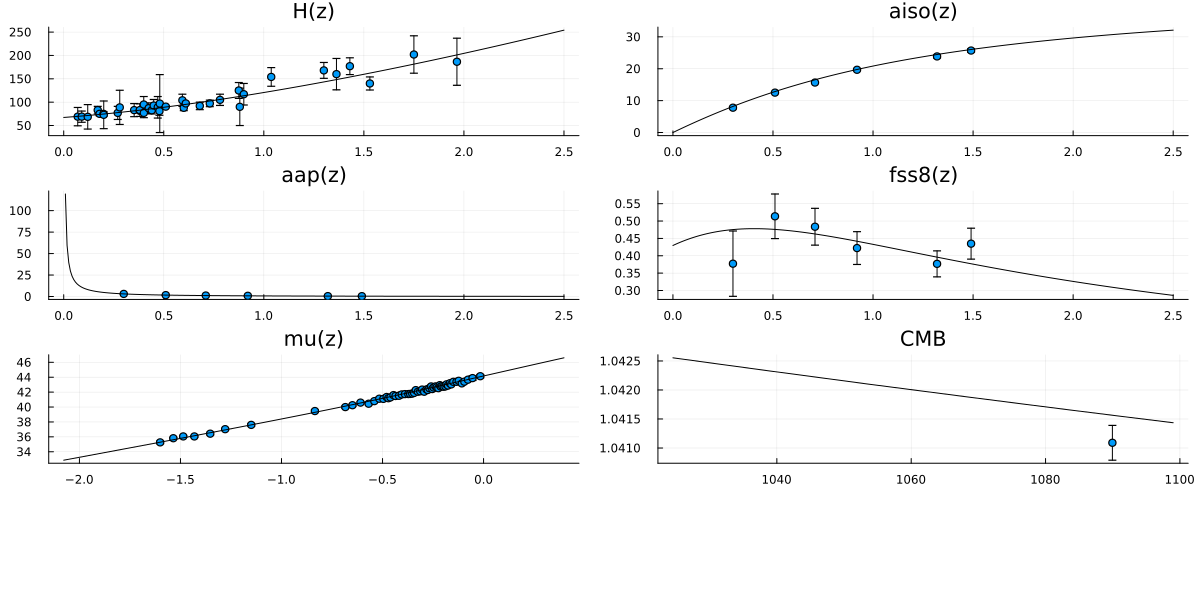

In [22]:
p0 = plot(datahz.z, datahz.data, yerr=hz_err, seriestype=:scatter,title="H(z)", legend=false)
p1 = plot(dataDESI.z1, dataDESI.data_dvrd, yerr=aiso_err, seriestype=:scatter,title="aiso(z)", legend=false)
p2 = plot(dataDESI.z1, dataDESI.data_dhdm, yerr=aap_err, seriestype=:scatter, title="aap(z)", legend=false)
p3 = plot(dataDESI.z1, dataDESI.data_fss8, yerr=fss8_err, seriestype=:scatter, title="fss8(z)", legend=false)
p4 = plot(log10.(datamu.z), datamu.data, yerr=mu_err, seriestype=:scatter, title="mu(z)", legend=false)
p5 = plot(dataCMB.z, dataCMB.data, yerr=CMB_err, seriestype=:scatter, title="CMB", legend=false)
# p6 = plot(dataDESI.z1, dataDESI.data_m, yerr=m_err, seriestype=:scatter, title="m(z)", legend=false)

plot!(p0, z_integ1, hz_from_ez(z_integ1, cosmo_fid.cpar.h, ez_fid_test), color=:black)
plot!(p1, z_integ1, a_iso(z_integ1, cosmo_fid.cpar.h, rd_red, ez_fid_test), color=:black)
plot!(p2, z_integ1, a_ap(z_integ1, cosmo_fid.cpar.h, ez_fid_test), color=:black)
plot!(p3, z_integ1, fss8_from_ez(z_integ1, z_integ1, ez_fid_test, k_integ, cosmo_fid.cpar.Ωm, cosmo_fid.cpar.σ8, cosmo_fid.cpar.h, r_d_fid, r_d_fid, cosmo_fid), color=:black)
plot!(p4, log10.(z_integ1), mu(z_integ1, z_integ1, cosmo_fid.cpar.h, ez_fid_test), color=:black)
plot!(p5, z_CMB[990:end], theta2(z_CMB, r_star, cosmo_fid.cpar.h, ez_CMB_test)[990:end], color=:black)
# plot!(p6, z_integ1, m_shapefit(z_integ1, z_integ1, cosmo_fid.cpar.Ωm, cosmo_fid.cpar.σ8, cosmo_fid.cpar.h, cosmo, cosmo_fid, ez_test, ez_fid_test, k_integ, kpiv), color=:black)

plot(p0, p1, p2, p3, p4, p5, layout=(4,2), size=(1200,600))

## LCDM analysis

In [23]:
data_obs = [datahz.data; datatracerfs8.data; dataDESI.data; datamu.data];
z_obs = [datahz.z; datatracerfs8.z; dataDESI.z; datamu.z];
covariance_obs = BlockDiagonal([datahz.cov, datatracerfs8.cov, dataDESI.cov, datamu.cov]);

In [24]:
@model function LCDM_model(data, data_cov)
    # Priors
    omegam_pr ~ omegam_dist
    h0_pr ~ h0_dist
    s8_pr ~ s8_dist
    rd_pr ~ rd_dist
    M_pr ~ M_dist

    T = typeof(s8_pr)

    # Create cosmology
    # cosmo_fid = LimberJack.Cosmology(Ωm=cosmo_fid.cpar.Ωm, Ωb=cosmo_fid.cpar.Ωb, h=cosmo_fid.cpar.h, σ8=s8_pr);
    cosmo_pr = LimberJack.Cosmology(Ωm = convert(T, cosmo_fid.cpar.Ωm), Ωb = convert(T, cosmo_fid.cpar.Ωb), h  = convert(T, cosmo_fid.cpar.h), σ8 = convert(T, cosmo_fid.cpar.σ8))
    cosmo_distribution = LimberJack.Cosmology(Ωm=omegam_pr, h=h0_pr, σ8=s8_pr, Ωb=0.0);

    # Model predictions
    ez_model = Ez(cosmo_pr, z_integ1)
    ez_CMB_model = Ez(cosmo_pr, z_CMB)
    hz_model := hz_from_ez(z_integ1, h0_pr, ez_model)
    dv_rd_model := a_iso(z_integ1, h0_pr, rd_pr, ez_model) 
    dh_dm_model := a_ap(z_integ1, h0_pr, ez_model)
    fss8_model := fss8_from_ez(z_integ1, z_integ1, ez_model, k_integ, omegam_pr, s8_pr, h0_pr, rd_pr, r_d_fid, cosmo_distribution)
    fs8_model := fs8_from_ez(z_integ1, omegam_pr, s8_pr, h0_pr, ez_model)[2]
    mu_model := mu(z_integ1, z_integ1, h0_pr, ez_model)
    # theta_model := theta2(z_CMB, r_star, h0_pr, ez_CMB_model)

    # Create interpolators
    hz_itp = LinearInterpolation(z_integ1, hz_model, extrapolation_bc=Line())
    fs8_itp = LinearInterpolation(z_integ1, fs8_model, extrapolation_bc=Line())
    dvrd_itp = LinearInterpolation(z_integ1, dv_rd_model, extrapolation_bc=Line())
    dhdm_itp = LinearInterpolation(z_integ1, dh_dm_model, extrapolation_bc=Line())
    fss8_itp = LinearInterpolation(z_integ1, fss8_model, extrapolation_bc=Line())
    mu_itp = LinearInterpolation(z_integ1, mu_model, extrapolation_bc=Line())
    # theta_itp = LinearInterpolation(z_CMB, theta_model, extrapolation_bc=Line())

    hz_theory := hz_itp(datahz.z)
    fs8_theory := fs8_itp(datatracerfs8.z)
    dvrd_theory := dvrd_itp(dataDESI.z1)
    dhdm_theory := dhdm_itp(dataDESI.z1)
    fss8_theory := fss8_itp(dataDESI.z1) 
    mu_theory := mu_itp(datamu.z)
    # theta_theory := theta_itp(dataCMB.z)


    DESI_theory = vec(permutedims(hcat(dvrd_theory, dhdm_theory, fss8_theory)))
    theory = [hz_theory; fs8_theory; DESI_theory; mu_theory]
    # Likelihood
    data ~ MvNormal(theory, data_cov)
end

LCDM_model (generic function with 2 methods)

In [25]:
chain_LCDM = sample(LCDM_model(data_obs, covariance_obs), NUTS(20, 0.75), 100)
lcdm_df_1 = DataFrame(chain_LCDM)
# CSV.write("lcdm_chain_finaltest_-cmb.csv", lcdm_df_1)

Sampling   0%|                                          |  ETA: N/A
┌ Warning: failed to find valid initial parameters in 10 tries; consider providing explicit initial parameters using the `initial_params` keyword
└ @ Turing.Inference /Users/vis/.julia/packages/Turing/QN7BL/src/mcmc/hmc.jl:192
Sampling 100%|██████████████████████████████████████████| Time: 0:00:42


InterruptException: InterruptException:

In [ ]:
CSV.write("lcdm_chain_finaltest_-cmb.csv", lcdm_df_1)

In [ ]:
# lcdm chains
hzdata_lcdm = group(chain_LCDM, :hz_model).value.data[:,:,1];
aisodata_lcdm = group(chain_LCDM, :dv_rd_model).value.data[:,:,1];
aapdata_lcdm = group(chain_LCDM, :dh_dm_model).value.data[:,:,1];
fs8data_lcdm = group(chain_LCDM, :fs8_model).value.data[:,:,1];
mudata_lcdm = group(chain_LCDM, :mu_model).value.data[:,:,1];
thetadata_lcdm = group(chain_LCDM, :theta_model).value.data[:,:,1];

# mean and standard deviation - lcdm
hz_lcdm_m, hz_lcdm_s = mean(hzdata_lcdm, dims=1), std(hzdata_lcdm, dims=1); 
aiso_lcdm_m, aiso_lcdm_s = mean(aisodata_lcdm, dims=1), std(aisodata_lcdm, dims=1);
aap_lcdm_m, aap_lcdm_s = mean(aapdata_lcdm, dims=1), std(aapdata_lcdm, dims=1); 
fs8_lcdm_m, fs8_lcdm_s = mean(fs8data_lcdm, dims=1), std(fs8data_lcdm, dims=1); 
mu_lcdm_m, mu_lcdm_s = mean(mudata_lcdm, dims=1), std(mudata_lcdm, dims=1); 
theta_lcdm_m, theta_lcdm_s = mean(thetadata_lcdm, dims=1), std(thetadata_lcdm, dims=1);

In [ ]:
plot(datahz.z, datahz.data, yerr=hz_err, label="Data H(z)", ms=2, seriestype=:scatter)
plot!(z_integ1, vec(hz_lcdm_m), label=" H(z) LCDM mean")
plot!(z_integ1, vec(hz_lcdm_m .- hz_lcdm_s),  fillrange = vec(hz_lcdm_m .+ hz_lcdm_s), fillalpha=0.2, c=1, label="H(z) LCDM standard deviation")

In [ ]:
plot(datafs8.z, dataDESI.data_dvrd, yerr=aiso_err, label="Data a_iso", ms=2, seriestype=:scatter)
plot!(z_integ1, vec(aiso_lcdm_m), label=" a_iso LCDM mean")
plot!(z_integ1, vec(aiso_lcdm_m .- aiso_lcdm_s),  fillrange = vec(aiso_lcdm_m .+ aiso_lcdm_s), fillalpha=0.2, c=1, label="a_iso LCDM standard deviation")

In [ ]:
plot(datafs8.z, dataDESI.data_dhdm, yerr=aap_err, label="Data a_ap", ms=2, seriestype=:scatter)
plot!(z_integ1, vec(aap_lcdm_m), label="a_ap LCDM mean")
plot!(z_integ1, vec(aap_lcdm_m .- aap_lcdm_s),  fillrange = vec(aap_lcdm_m .+ aap_lcdm_s), fillalpha=0.2, c=1, yscale=:log10, label="a_ap LCDM standard deviation")

In [ ]:
plot(datafs8.z, datafs8.data, yerr=fs8_err, label="Data fs8", ms=2, seriestype=:scatter)
plot!(z_integ1, vec(fs8_lcdm_m), label="fs8 lcdm")
plot!(z_integ1, vec(fs8_lcdm_m .- fs8_lcdm_s),  fillrange = vec(fs8_lcdm_m .+ fs8_lcdm_s), fillalpha=0.2, c=1, label="fs8 lcdm standard deviation")

In [ ]:
plot(dataCMB.z, dataCMB.data, yerr=CMB_err, label="Data CMB", ms=2, seriestype=:scatter)
plot!(z_integ1, vec(theta_lcdm_m), label="CMB lcdm")
plot!(z_integ1, vec(theta_lcdm_m .- theta_lcdm_s),  fillrange = vec(theta_lcdm_m .+ theta_lcdm_s), fillalpha=0.2, c=1, label="CMB lcdm standard deviation")

In [ ]:
plot(log10.(datamu.z), datamu.data, yerr=mu_err, label="Data mu", ms=2, seriestype=:scatter)
plot!(log10.(z_integ1), vec(mu_lcdm_m), label="mu lcdm")
plot!(log10.(z_integ1), vec(mu_lcdm_m .- mu_lcdm_s),  fillrange = vec(mu_lcdm_m .+ mu_lcdm_s), fillalpha=0.2, c=1, label="mu lcdm standard deviation")

## GP analysis

In [ ]:
zlat = range(0, 2.5, length=15); # latent variable space
# zlat_CMB = logrange(1.0, 1100.0, length=15) .- 1.0;
z_integ = range(0.0, 2.5, length=300); # integral variable space

@model function stats_model(y, data_cov; int_grid=z_integ, X=zlat, data_x=z_obs)
    # Priors, parameters
    eta2 = 0.2
    l2 = 1.0
    # l_cmb = 10.0
    v_po ~ MvNormal(zeros(length(X)), ones(length(X)))
    omegam_po ~ omegam_dist
    s8_po ~ s8_dist
    h_po ~ h0_dist
    r_po ~ rd_dist
    M_po ~ M_dist
    
    
    kernel = sqexp_cov_fn(X, eta=eta2, l=l2)
    # kernel_CMB = sqexp_cov_fn(zlat_CMB, eta=eta2, l=l_cmb)
    cosmo_po = CosmoPar(Ωm=cosmo_fid.cpar.Ωm, Ωb=cosmo_fid.cpar.Ωb, h=cosmo_fid.cpar.h, σ8=s8_po)
    cosmo_distribution = LimberJack.Cosmology(Ωm=omegam_po, h=h_po, σ8=s8_po);
    
    mean_ez = Ez(cosmo_po, X)
    # mean_ez_CMB = Ez(cosmo_po, zlat_CMB)
    ez_latent = latent_GP(mean_ez, v_po, kernel)
    # ez_CMB_latent = latent_GP(mean_ez_CMB, v_po, kernel_CMB)
    ez_gp = conditional(X, int_grid, ez_latent, sqexp_cov_fn; eta=eta2, l=l2) # converting from latent space to integral space
    # ez_CMB_gp = conditional(zlat_CMB, z_CMB, ez_CMB_latent, sqexp_cov_fn; eta=eta2, l=l_cmb) # converting from latent space to CMB integral space

    # sampling over parameters
    hz_mod := hz_from_ez(int_grid, h_po, ez_gp);
    aiso_mod := a_iso(int_grid, h_po, r_po, ez_gp);
    aap_mod := a_ap(int_grid, h_po, ez_gp);
    fss8_mod := fss8_from_ez(int_grid, int_grid, ez_gp, k_integ, omegam_po, s8_po, h_po, r_d_fid, cosmo_distribution);
    fs8_mod := fs8_from_ez(int_grid, omegam_po, s8_po, h_po, ez_gp)[2]
    mu_mod := mu(int_grid, int_grid, h_po, ez_gp);
    # theta_mod := theta2(z_CMB, r_star, h_po, ez_CMB_gp)

    hz_interp = LinearInterpolation(int_grid, hz_mod, extrapolation_bc=Line())
    aiso_interp = LinearInterpolation(int_grid, aiso_mod, extrapolation_bc=Line())
    aap_interp = LinearInterpolation(int_grid, aap_mod, extrapolation_bc=Line())
    fss8_interp = LinearInterpolation(int_grid, fss8_mod, extrapolation_bc=Line())
    fs8_interp = LinearInterpolation(int_grid, fs8_mod, extrapolation_bc=Line())
    mu_interp = LinearInterpolation(int_grid, mu_mod, extrapolation_bc=Line())
    # theta_interp = LinearInterpolation(z_CMB, theta_mod, extrapolation_bc=Line())

    hdata := hz_interp(datahz.z)
    aisodata := aiso_interp(dataDESI.z1)
    aapdata := aap_interp(dataDESI.z1)
    fs8data := fs8_interp(datatracerfs8.z)
    fss8data := fss8_interp(dataDESI.z1)
    mudata := mu_interp(datamu.z)
    # thetadata := theta_interp(dataCMB.z)

    DESIdata = vec(permutedims(hcat(aisodata, aapdata, fss8data)))
    datay = [hdata; fs8data; DESIdata; mudata]

    y ~ MvNormal(datay, data_cov)

end

In [ ]:
chain_gp = sample(stats_model(data_obs, covariance_obs), NUTS(20, 0.75), 100)
gp_df_1 = DataFrame(chain_gp)
CSV.write("gp_chain_finaltest.csv", gp_df_1)

In [ ]:
# data posterior gp chains
hdata_p = group(chain_gp, :hz_mod).value.data[:,:,1];
aisodata_p = group(chain_gp, :aiso_mod).value.data[:,:,1];
aapdata_p =  group(chain_gp, :aap_mod).value.data[:,:,1];
fs8data_p =  group(chain_gp, :fs8_mod).value.data[:,:,1];
mudata_p =  group(chain_gp, :mu_mod).value.data[:,:,1];

# parameter chains
v_p = group(chain_gp, :v_po).value.data[:, :, 1];
omegam_p = group(chain_gp, :omegam_po).value.data[:, :, 1];
s8_p = group(chain_gp, :s8_po).value.data[:, :, 1];

# data mean / standard dev.
hpmean, hps = mean(hdata_p, dims=1), std(hdata_p, dims=1);
aisopmean, aisops = mean(aisodata_p, dims=1), std(aisodata_p, dims=1);
aappmean, aapps = mean(aapdata_p, dims=1), std(aapdata_p, dims=1);
fs8pmean, fs8ps = mean(fs8data_p, dims=1), std(fs8data_p, dims=1);
mupmean, mups = mean(mudata_p, dims=1), std(mudata_p, dims=1);

In [ ]:
plot(datahz.z, datahz.data, yerr=hz_err, label="Data hz", ms=2, seriestype=:scatter)
plot!(z_integ1, vec(hpmean), label="hz GP mean")
plot!(z_integ1, vec(hpmean .- hps),  fillrange = vec(hpmean .+ hps), fillalpha=0.2, c=4, label="hz GP standard deviation")
plot!(z_integ1, vec(hz_lcdm_m), label=" H(z) LCDM mean")
plot!(z_integ1, vec(hz_lcdm_m .- hz_lcdm_s),  fillrange = vec(hz_lcdm_m .+ hz_lcdm_s), fillalpha=0.2, c=1, label="H(z) LCDM standard deviation")

In [ ]:
p0 = plot(datahz.z, datahz.data, yerr=hz_err, seriestype=:scatter,label="H(z)")
p1 = plot(datafs8.z, dataDESI.data_dvrd, yerr=aiso_err, seriestype=:scatter,label="aiso(z)")
p2 = plot(datafs8.z, dataDESI.data_dhdm, yerr=aap_err, seriestype=:scatter, label="aap(z)")
p3 = plot(datafs8.z, datafs8.data, yerr=fs8_err, seriestype=:scatter, label="fs8(z)")
p4 = plot(datamu.z, datamu.data, yerr=mu_err, seriestype=:scatter, label="mu(z)")


plot!(p0, z_integ1, vec(hpmean), label="hz GP mean")
plot!(p0, z_integ1, vec(hpmean .- hps),  fillrange = vec(hpmean .+ hps), fillalpha=0.2, c=4, label="H(z) GP standard deviation")
plot!(p0, z_integ1, vec(hz_lcdm_m), label="H(z) LCDM mean")
plot!(p0, z_integ1, vec(hz_lcdm_m .- hz_lcdm_s),  fillrange = vec(hz_lcdm_m .+ hz_lcdm_s), fillalpha=0.2, c=1, label="H(z) LCDM standard deviation")


plot!(p1, z_integ1, vec(aisopmean), label="a_iso GP mean")
plot!(p1, z_integ1, vec(aisopmean .- aisops),  fillrange = vec(aisopmean .+ aisops), fillalpha=0.2, c=4, label="a_iso GP standard deviation")
plot!(p1, z_integ1, vec(aiso_lcdm_m), label="a_iso LCDM mean")
plot!(p1, z_integ1, vec(aiso_lcdm_m .- aiso_lcdm_s),  fillrange = vec(aiso_lcdm_m .+ aiso_lcdm_s), fillalpha=0.2, c=1, label="a_iso LCDM standard deviation")


plot!(p2, z_integ1, vec(aappmean), label="a_ap GP mean")
plot!(p2, z_integ1, vec(aappmean .- aapps),  fillrange = vec(aappmean .+ aapps), fillalpha=0.2, c=4, label="a_ap GP standard deviation")
plot!(p2, z_integ1, vec(aap_lcdm_m), label="a_ap LCDM mean")
plot!(p2, z_integ1, vec(aap_lcdm_m .- aap_lcdm_s),  fillrange = vec(aap_lcdm_m .+ aap_lcdm_s), fillalpha=0.2, c=1, label="a_ap LCDM standard deviation")


plot!(p3, z_integ1, vec(fs8pmean), label="fs8 GP mean")
plot!(p3, z_integ1, vec(fs8pmean .- fs8ps),  fillrange = vec(fs8pmean .+ fs8ps), fillalpha=0.2, c=4, label="fs8 GP standard deviation")
plot!(p3, z_integ1, vec(fs8_lcdm_m), label="fs8 LCDM mean")
plot!(p3, z_integ1, vec(fs8_lcdm_m .- fs8_lcdm_s),  fillrange = vec(fs8_lcdm_m .+ fs8_lcdm_s), fillalpha=0.2, c=1, label="fs8 LCDM standard deviation")


plot!(p4, z_integ1, vec(mupmean), label="mu GP mean")
plot!(p4, z_integ1, vec(mupmean .- mups),  fillrange = vec(mupmean .+ mups), fillalpha=0.2, c=4, label="mu GP standard deviation")
plot!(p4, z_integ1, vec(mu_lcdm_m), label="mu LCDM mean")
plot!(p4, z_integ1, vec(mu_lcdm_m .- mu_lcdm_s),  fillrange = vec(mu_lcdm_m .+ mu_lcdm_s), fillalpha=0.2, c=1, label="mu LCDM standard deviation")

plot(p0, p1, p2, p3, p4, layout=(2,3), size=(1600,1000))

In [ ]:
using MCMCChains
dfrhat = rhat(chain_LCDM);
v = collect(dfrhat[:, :rhat])
nbad = sum(abs.(v .- 1) .> 0.6)